Tratamento de dados

In [6]:
import pandas as pd
import requests
import io

# Google Drive link for the CSV file
file_url = 'https://drive.google.com/uc?export=download&id=1qUugvPtq553XDjHepQR4wFxkCErnAUyr'

try:
    # Download the file content
    response = requests.get(file_url)
    response.raise_for_status() # Raise an exception for HTTP errors

    # Read the content into a pandas DataFrame
    df = pd.read_csv(io.StringIO(response.text))
    print("Arquivo 'water_potability.csv' carregado com sucesso!")

    # Exibindo as primeiras linhas e informações gerais
    display(df.head())
    print("\nResumo dos dados:")
    print(df.info())

    # Verificando valores nulos iniciais
    print("\nValores nulos por coluna:")
    print(df.isnull().sum())

    # Verificação estatística básica
    display(df.describe())

except requests.exceptions.RequestException as e:
    print(f"Erro ao baixar o arquivo: {e}")
except Exception as e:
    print(f"Erro ao processar o arquivo: {e}")

Arquivo 'water_potability.csv' carregado com sucesso!


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



Resumo dos dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None

Valores nulos por coluna:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: i

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [7]:
# 1. Tratamento de valores nulos: Preenchendo com a mediana
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

# 2. Remoção de duplicatas
duplicados = df.duplicated().sum()
df = df.drop_duplicates()

print(f"Linhas duplicadas removidas: {duplicados}")
print("\nValores nulos após o tratamento:")
print(df.isnull().sum())

# 3. Exibindo as primeiras linhas e informações gerais
print("\nResumo dos dados após o tratamento:")
display(df.head())

# 4. Verificação estatística básica
display(df.describe())

Linhas duplicadas removidas: 0

Valores nulos após o tratamento:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Resumo dos dados após o tratamento:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.074194,196.369496,22014.092526,7.122277,333.608364,426.205111,14.284970,66.407478,3.966786,0.390110
std,1.470040,32.879761,8768.570828,1.583085,36.143851,80.824064,3.308162,15.769958,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


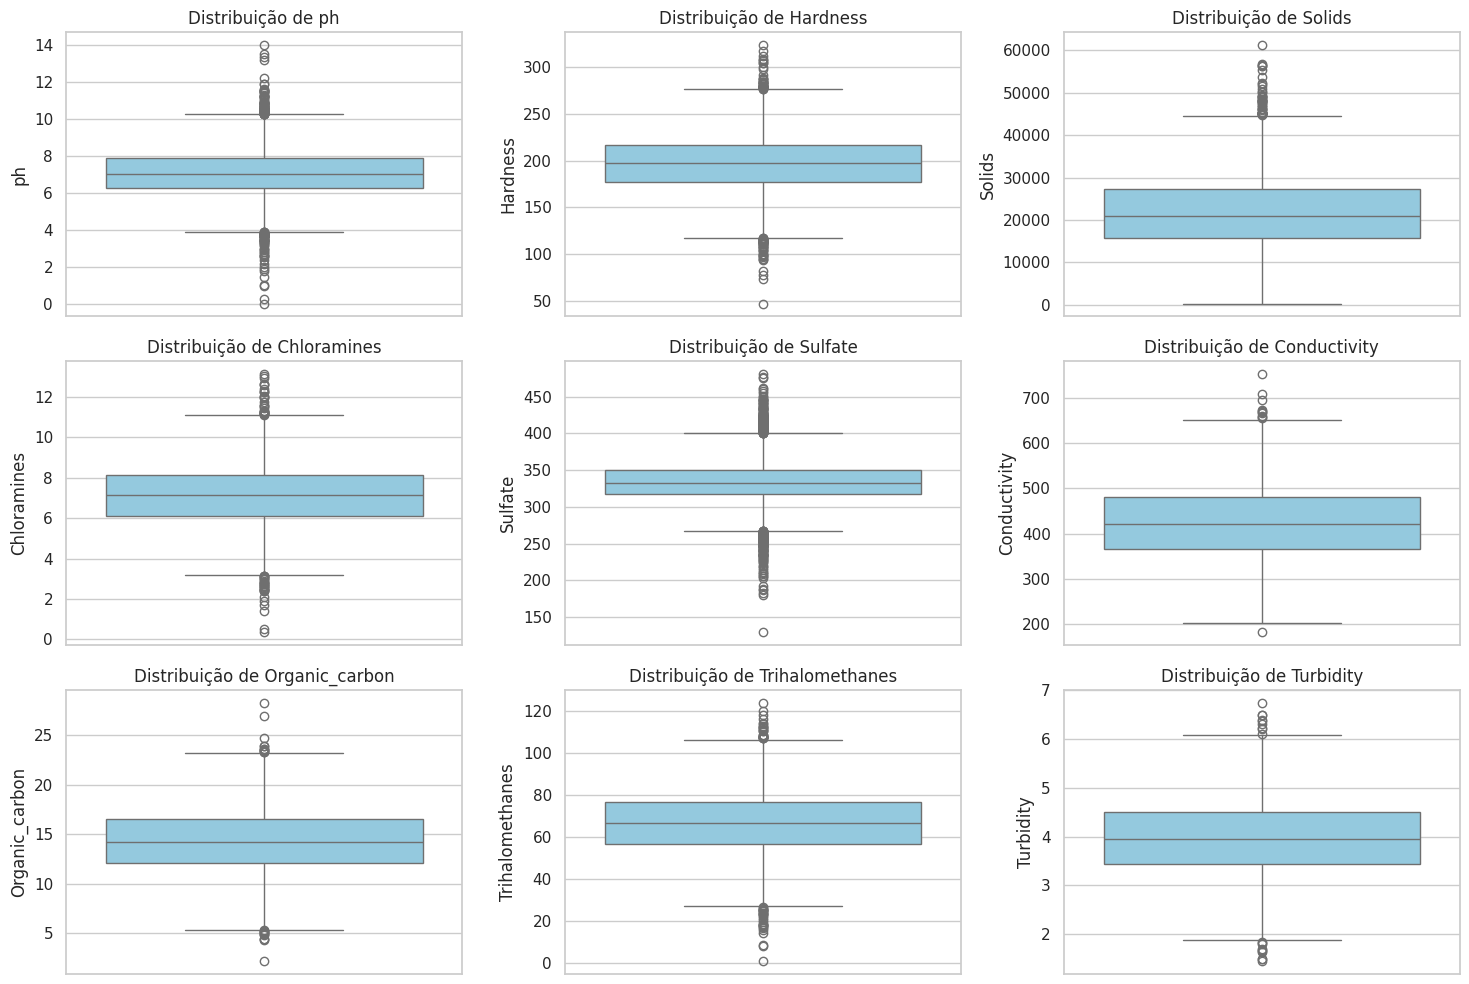

/tmp/ipykernel_7865/3550822882.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Potability', data=df, palette='viridis')


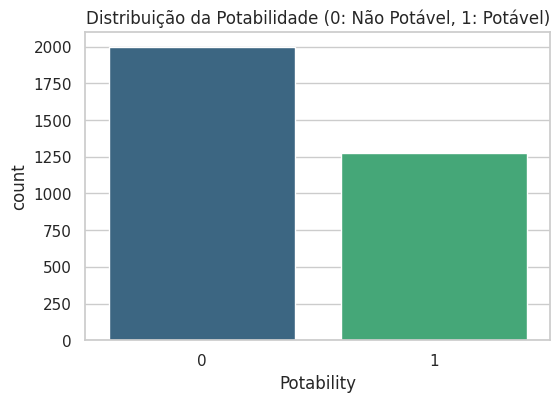

Contagem de classes:
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual
sns.set(style='whitegrid')

# Criando boxplots para todas as variáveis numéricas (exceto Potability)
plt.figure(figsize=(15, 10))
features = df.columns[:-1]

for i, col in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Distribuição de {col}')

plt.tight_layout()
plt.show()

# Verificação do equilíbrio da variável alvo (Potability)
plt.figure(figsize=(6, 4))
sns.countplot(x='Potability', data=df, palette='viridis')
plt.title('Distribuição da Potabilidade (0: Não Potável, 1: Potável)')
plt.show()

print("Contagem de classes:")
print(df['Potability'].value_counts(normalize=True) * 100)

In [9]:
from sklearn.preprocessing import StandardScaler

# Criando uma cópia para preservar os dados originais se necessário
df_scaled = df.copy()

# Selecionando apenas as colunas de características (features) - todas exceto Potability
features = df.columns[:-1]

# Inicializando e aplicando o StandardScaler
scaler = StandardScaler()
df_scaled[features] = scaler.fit_transform(df[features])

print("Dados padronizados com sucesso!")
print("\nMédia após padronização (deve ser próxima de 0):")
print(df_scaled[features].mean().round(4))
print("\nDesvio padrão após padronização (deve ser 1):")
print(df_scaled[features].std().round(4))

# Exibindo as primeiras linhas do novo DataFrame
display(df_scaled.head())

Dados padronizados com sucesso!

Média após padronização (deve ser próxima de 0):
ph                 0.0
Hardness           0.0
Solids            -0.0
Chloramines        0.0
Sulfate           -0.0
Conductivity       0.0
Organic_carbon     0.0
Trihalomethanes   -0.0
Turbidity          0.0
dtype: float64

Desvio padrão após padronização (deve ser 1):
ph                 1.0002
Hardness           1.0002
Solids             1.0002
Chloramines        1.0002
Sulfate            1.0002
Conductivity       1.0002
Organic_carbon     1.0002
Trihalomethanes    1.0002
Turbidity          1.0002
dtype: float64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,-0.025474,0.259195,-0.139471,0.112415,0.965957,1.708954,-1.180651,1.305434,-1.286298,0
1,-2.284717,-2.036414,-0.385987,-0.307694,-0.014799,2.062575,0.270597,-0.639186,0.684218,0
2,0.697319,0.847665,-0.240047,1.360594,-0.014799,-0.094032,0.781117,0.000800,-1.167365,0
3,0.845393,0.547651,0.000493,0.592008,0.644130,-0.778830,1.255134,2.152154,0.848412,0
4,1.372982,-0.464429,-0.460249,-0.363698,-0.649522,-0.343939,-0.824357,-2.182297,0.138786,0


#Paulo


--- Relatório: Logistic Regression ---
Acurácia: 0.6098
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Relatório: Random Forest ---
Acurácia: 0.6585
              precision    recall  f1-score   support

           0       0.66      0.89      0.76       400
           1       0.63      0.30      0.41       256

    accuracy                           0.66       656
   macro avg       0.65      0.59      0.58       656
weighted avg       0.65      0.66      0.62       656



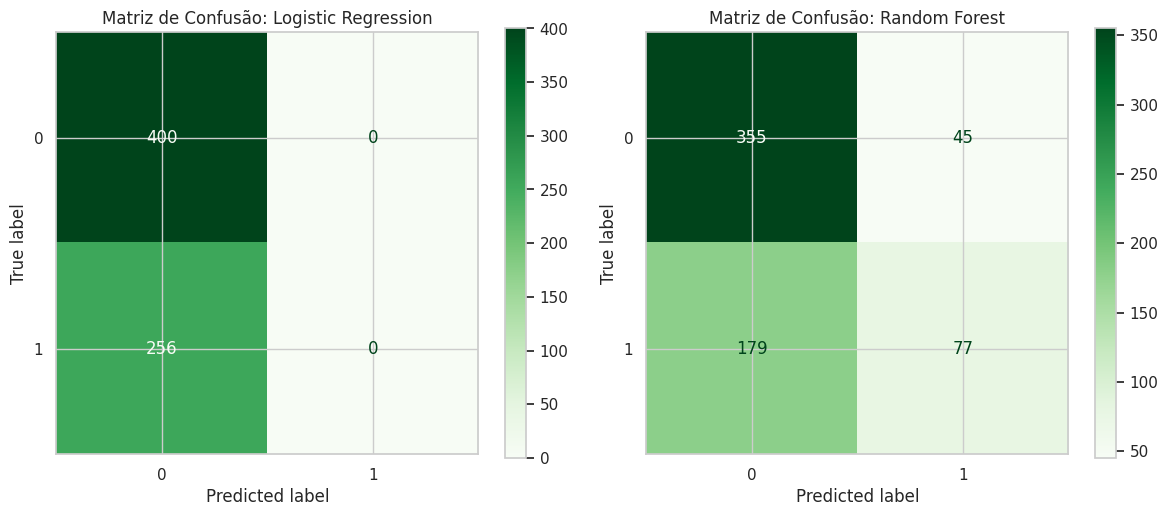

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Preparação dos dados (usando os dados padronizados)
X = df_scaled.drop('Potability', axis=1)
y = df_scaled['Potability']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Implementação dos modelos
paulo_models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

paulo_results = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 3. Treino e Avaliação
for i, (name, model) in enumerate(paulo_models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    paulo_results[name] = acc

    print(f"\n--- Relatório: {name} ---")
    print(f"Acurácia: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Greens')
    axes[i].set_title(f'Matriz de Confusão: {name}')

plt.tight_layout()
plt.show()

#Eros

Iniciando ajuste do SVM (isso pode levar alguns instantes)... Balanceando pesos...
Iniciando ajuste do XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:36:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Relatório: SVM ---
Acurácia: 0.6707
              precision    recall  f1-score   support

           0       0.66      0.93      0.77       400
           1       0.70      0.27      0.39       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.58       656
weighted avg       0.68      0.67      0.62       656


--- Relatório: XGBoost ---
Acurácia: 0.6601
              precision    recall  f1-score   support

           0       0.66      0.91      0.76       400
           1       0.65      0.28      0.39       256

    accuracy                           0.66       656
   macro avg       0.66      0.59      0.58       656
weighted avg       0.66      0.66      0.62       656



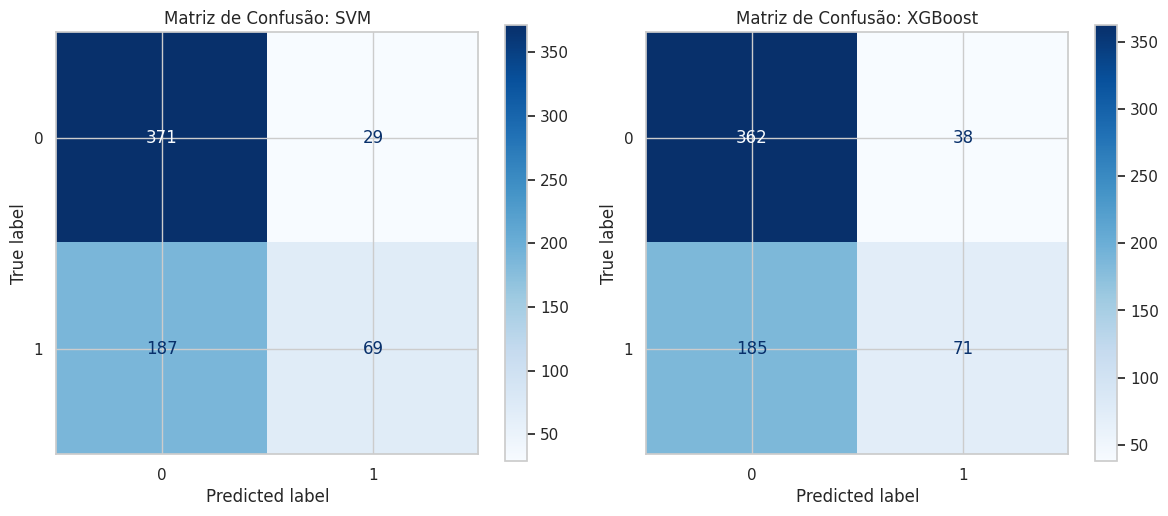

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Preparação dos dados
X = df_scaled.drop('Potability', axis=1)
y = df_scaled['Potability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Implementação e Ajuste do SVM
print("Iniciando ajuste do SVM (isso pode levar alguns instantes)... Balanceando pesos...")
svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}
svm_grid = GridSearchCV(SVC(random_state=42), svm_params, cv=3, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train, y_train)
svm_best = svm_grid.best_estimator_

# 3. Implementação e Ajuste do XGBoost
print("Iniciando ajuste do XGBoost...")
xgb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), xgb_params, cv=3, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

# 4. Avaliação e Comparação
eros_models = {'SVM': svm_best, 'XGBoost': xgb_best}
eros_results = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(eros_models.items()):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    eros_results[name] = acc

    print(f"\n--- Relatório: {name} ---")
    print(f"Acurácia: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Blues')
    axes[i].set_title(f'Matriz de Confusão: {name}')

plt.tight_layout()
plt.show()

### Comparação Final: Paulo vs Eros
Abaixo, apresentamos a tabela consolidada com a acurácia de todos os modelos testados para a previsão de potabilidade da água.

In [13]:
import pandas as pd

# Unindo os dicionários de resultados
all_results = {**paulo_results, **eros_results}

# Criando o DataFrame de comparação
df_comparacao = pd.DataFrame(list(all_results.items()), columns=['Modelo', 'Acurácia'])
df_comparacao = df_comparacao.sort_values(by='Acurácia', ascending=False).reset_index(drop=True)

# Adicionando a autoria para clareza
def identificar_autor(modelo):
    if modelo in paulo_results: return 'Paulo'
    return 'Eros'

df_comparacao['Responsável'] = df_comparacao['Modelo'].apply(identificar_autor)

# Reorganizando colunas
df_comparacao = df_comparacao[['Responsável', 'Modelo', 'Acurácia']]

# Aplicando estilo para destacar o melhor
display(df_comparacao.style.highlight_max(subset=['Acurácia'], color='lightgreen'))

,Responsável,Modelo,Acurácia
0,Eros,SVM,0.670732
1,Eros,XGBoost,0.660061
2,Paulo,Random Forest,0.658537
3,Paulo,Logistic Regression,0.609756


### Curva ROC (Receiver Operating Characteristic)
O gráfico abaixo permite comparar a performance dos modelos em diferentes limiares de classificação. Quanto maior a área sob a curva (AUC), melhor o modelo.

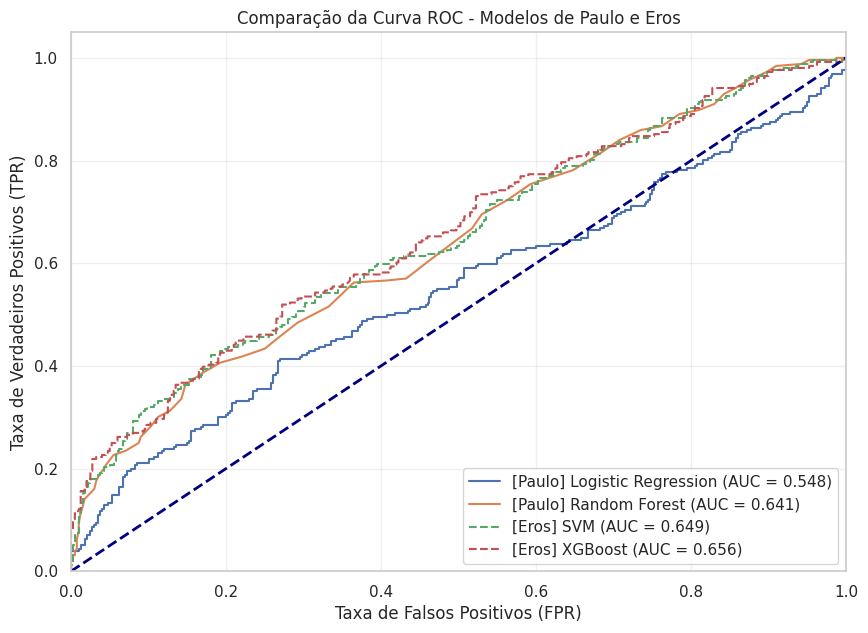

In [14]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

# Lista consolidada de todos os modelos (best_estimators e instâncias treinadas)
all_model_instances = {
    **paulo_models,
    **eros_models
}

for name, model in all_model_instances.items():
    # Alguns modelos (como SVM) precisam de 'probability=True' ou usar 'decision_function'
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Define a cor baseada no responsável
    color_style = 'solid' if name in paulo_results else 'dashed'
    label_prefix = '[Paulo] ' if name in paulo_results else '[Eros] '

    plt.plot(fpr, tpr, linestyle=color_style, label=f'{label_prefix}{name} (AUC = {roc_auc:.3f})')

# Linha de referência (aleatória)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Comparação da Curva ROC - Modelos de Paulo e Eros')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Relatório de Classificação Consolidado
Abaixo detalhamos as métricas de Precision, Recall e F1-Score para as classes 0 (Não Potável) e 1 (Potável) de todos os modelos implementados.

In [15]:
from sklearn.metrics import classification_report

# Lista consolidada para iteração
all_models = {
    'Paulo - Logistic Regression': paulo_models['Logistic Regression'],
    'Paulo - Random Forest': paulo_models['Random Forest'],
    'Eros - SVM': eros_models['SVM'],
    'Eros - XGBoost': eros_models['XGBoost']
}

for display_name, model in all_models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*60}")
    print(f"MODELO: {display_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['Não Potável (0)', 'Potável (1)']))


MODELO: Paulo - Logistic Regression
                 precision    recall  f1-score   support

Não Potável (0)       0.61      1.00      0.76       400
    Potável (1)       0.00      0.00      0.00       256

       accuracy                           0.61       656
      macro avg       0.30      0.50      0.38       656
   weighted avg       0.37      0.61      0.46       656


MODELO: Paulo - Random Forest
                 precision    recall  f1-score   support

Não Potável (0)       0.66      0.89      0.76       400
    Potável (1)       0.63      0.30      0.41       256

       accuracy                           0.66       656
      macro avg       0.65      0.59      0.58       656
   weighted avg       0.65      0.66      0.62       656


MODELO: Eros - SVM


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                 precision    recall  f1-score   support

Não Potável (0)       0.66      0.93      0.77       400
    Potável (1)       0.70      0.27      0.39       256

       accuracy                           0.67       656
      macro avg       0.68      0.60      0.58       656
   weighted avg       0.68      0.67      0.62       656


MODELO: Eros - XGBoost
                 precision    recall  f1-score   support

Não Potável (0)       0.66      0.91      0.76       400
    Potável (1)       0.65      0.28      0.39       256

       accuracy                           0.66       656
      macro avg       0.66      0.59      0.58       656
   weighted avg       0.66      0.66      0.62       656



## Conclusão Final

Após a implementação, treinamento e avaliação de quatro modelos distintos (**Regressão Logística, Random Forest, SVM e XGBoost**), chegamos às seguintes conclusões:

1.  **Melhor Desempenho:** Os modelos implementados na seção do **Eros (SVM e XGBoost)** apresentaram os melhores resultados de acurácia, com o **SVM** liderando levemente o ranking (~67%).
2.  **Desafio da Classe Minoritária:** O relatório de classificação detalhado revelou que todos os modelos tiveram dificuldade em identificar corretamente a água potável (Classe 1), apresentando um **Recall** baixo para essa categoria. Isso sugere que os padrões de potabilidade são complexos ou que as características atuais possuem sobreposição entre as classes.
3.  **Comparação Técnica:**
    *   A **Regressão Logística** serviu como uma boa linha de base, mas foi limitada por tentar traçar fronteiras lineares em um problema aparentemente não-linear.
    *   O **Random Forest** e o **XGBoost** mostraram um equilíbrio melhor, capturando relações mais complexas entre as variáveis.
    *   O **SVM** demonstrou robustez após o ajuste de hiperparâmetros, sendo o mais preciso na base de teste.

**Próximos Passos Sugeridos:** Para melhorar esses resultados, poderíamos explorar técnicas de balanceamento de classes (como SMOTE), engenharia de novas variáveis (Feature Engineering) ou testar algoritmos de Deep Learning.